# Some quick start code for TUM Hackathon

In [1]:
from langchain.document_loaders import PyPDFLoader
from ai_eval.config import global_config as glob
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_ollama import ChatOllama, OllamaEmbeddings

filename = "attention.pdf"

loader = PyPDFLoader(f"{glob.DATA_PKG_DIR}/{filename}")

raw_data = loader.load()

texts = [page.page_content for page in raw_data]

print(f"Number of docs: {len(texts)}")

/Users/qtf4195/tum-hackathon/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of docs: 8


## (Optional) Preprocess and load data: 

In [2]:
from ai_eval.resources.preprocessor import Preprocessor
from ai_eval.config import global_config as glob

filename = "attention.pdf"

pre = Preprocessor()

docs = pre.fetch_documents(
    blob_path=f"{glob.DATA_PKG_DIR}/{filename}", source="local"
)

documents = pre.chunk_documents(documents=docs)

print(f"Number of processed document chunks: {len(documents)}")

2025-11-22 13:11:52,398 - ai_eval.resources.preprocessor - INFO - Processed /Users/qtf4195/tum-hackathon/data/attention.pdf
2025-11-22 13:11:52,399 - ai_eval.resources.preprocessor - INFO - Using SentenceChunker for document chunking.


Finished 'fetch_documents' in 0.0666 secs


🦛 choooooooooooooooooooonk 100% • 8/8 docs chunked [00:00<00:00, 21.40doc/s] 🌱
2025-11-22 13:11:53,379 - ai_eval.resources.preprocessor - INFO - Chunked 8 pages into 15 chunks.


Finished 'chunk_documents' in 0.9835 secs
Number of processed document chunks: 15


## Get annotated data:

In [3]:
from ai_eval.services.file import JSONService
from ai_eval.config import global_config as glob

json = JSONService(path="generated_qa_data_tum.json", root_path=glob.DATA_PKG_DIR, verbose=True)

qa_data = json.doRead()
print(f"Number of evaluation data samples: {len(qa_data)}")

2025-11-22 13:11:55,913 - ai_eval.services.file - INFO - Read: /Users/qtf4195/tum-hackathon/data/generated_qa_data_tum.json


Number of evaluation data samples: 100


### Fit RAG model on the generated data and create evaluation dataset

In [4]:
from ai_eval.resources import eval_dataset_builder as eval

ground_truth_contexts = [item["context"] for item in qa_data]
sample_queries = [item["question"] for item in qa_data]
expected_responses = [item["answer"] for item in qa_data]

Example: using OpenAI models

In [5]:

print("Model Provider: ", glob.MODEL_PROVIDER)
if True:
    chat_model = ChatOpenAI(
                            model="gpt-4o-mini",
                            temperature=0.1,
                            max_retries=2,
                        )

    embedding_model = OpenAIEmbeddings(
                            model="text-embedding-3-small",
                        )
else:
    chat_model = ChatOllama(
                            model="llama3.1:latest",
                            temperature=0.1,
                            max_retries=2,
                        )

    embedding_model = OllamaEmbeddings(
                            model="nomic-embed-text",
                        )   

Model Provider:  ollama


## RAG-Anything Integration (Optimized Multimodal RAG)

Using RAG-Anything for advanced document processing with support for:
- Multimodal content (text, images, tables, formulas)
- Better document parsing with MinerU
- Optimized chunking and retrieval


In [8]:
# Install and import RAG-Anything
# First time setup: pip install raganything nest-asyncio
import os
import asyncio
from pathlib import Path

try:
    from raganything import RAGAnything, RAGAnythingConfig
    from ai_eval.resources.rag_template import RAGAnythingRAG
    from langchain.docstore.document import Document
    import nest_asyncio
    nest_asyncio.apply()  # Allow nested event loops in Jupyter
except ImportError as e:
    print(f"Missing dependency: {e}")
    print("Please install: pip install raganything nest-asyncio")
    raise

# Set up RAG-Anything
# Get API key from environment or config (for LLM/embedding functions)
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    # Try to get from config if available
    try:
        api_key = getattr(glob, "OPENAI_API_KEY", None)
    except:
        pass

if not api_key:
    print("Warning: OPENAI_API_KEY not found. RAG-Anything may not work without an API key.")
    print("Set it with: export OPENAI_API_KEY='your-key' or in your .env file")

# Create configuration with optimized settings
config = RAGAnythingConfig(
    working_dir="./rag_storage",
    parser="mineru",  # Use MinerU for better PDF parsing
    parse_method="auto",  # Auto-detect best parsing method
    parser_output_dir="./output",
    enable_image_processing=True,
    enable_table_processing=True,
    enable_equation_processing=True,
    display_content_stats=True,
)

print("✓ RAG-Anything configuration created!")
print("Note: RAG-Anything will be initialized after chat_model and embedding_model are set up.")


✓ RAG-Anything configuration created!
Note: RAG-Anything will be initialized after chat_model and embedding_model are set up.


## Step 2: Initialize RAG-Anything

**⚠️ IMPORTANT: Run this cell BEFORE Step 3!**

Initialize RAG-Anything with model functions. This must be done AFTER `chat_model` and `embedding_model` are set up (from cell 9).


In [9]:
# Initialize RAG-Anything with model functions
# RAG-Anything requires LLM and embedding functions during initialization to create LightRAG

def llm_func(prompt, **kwargs):
    """LLM function for RAG-Anything."""
    response = chat_model.invoke(prompt)
    if hasattr(response, "content"):
        return response.content
    return str(response)

def embedding_func(texts):
    """Embedding function for RAG-Anything."""
    if isinstance(texts, str):
        texts = [texts]
    # Get embeddings
    embeddings = embedding_model.embed_documents(texts)
    return embeddings

# Now initialize RAG-Anything with the model functions
# This creates the LightRAG instance internally
rag_anything = RAGAnything(
    config=config,
    llm_model_func=llm_func,
    embedding_func=embedding_func,
)

print("✓ RAG-Anything initialized with model functions!")
print("LightRAG instance created and ready for document processing.")

# Create RAG-Anything RAG instance (compatible with evaluation framework)
# This wrapper integrates RAG-Anything with your existing RAG interface

rag_anything_rag = RAGAnythingRAG(
    llm=chat_model,
    documents=None,  # RAG-Anything manages its own documents
    k=3,  # Number of documents to retrieve
    rag_anything_instance=rag_anything,
    processed_docs_cache=None  # Optional: pre-loaded documents
)

print("✓ RAG-Anything RAG instance created!")
print("This instance is compatible with your evaluation framework.")


INFO: RAGAnything initialized with config:
INFO:   Working directory: ./rag_storage
INFO:   Parser: mineru
INFO:   Parse method: auto
INFO:   Multimodal processing - Image: True, Table: True, Equation: True
INFO:   Max concurrent files: 1


✓ RAG-Anything initialized with model functions!
LightRAG instance created and ready for document processing.
✓ RAG-Anything RAG instance created!
This instance is compatible with your evaluation framework.


In [10]:
# Step 3: Process & Store Documents (One-Time Operation)
# ========================================================
# This cell processes the document and stores it in RAG-Anything's storage.
# Run this ONCE. After processing, you can skip this step in future runs.

# Check if RAG-Anything is initialized
try:
    if 'rag_anything' not in globals() or rag_anything is None:
        raise NameError("rag_anything not initialized")
    if not hasattr(rag_anything, 'lightrag') or rag_anything.lightrag is None:
        raise ValueError("RAG-Anything not properly initialized. Please run Step 2 first!")
except (NameError, ValueError) as e:
    print(f"❌ ERROR: {e}")
    print("\nPlease run Step 2 (cell 13) first to initialize RAG-Anything with model functions.")
    print("The initialization requires chat_model and embedding_model to be set up first.")
    raise

# Configuration
output_dir = "./output/raganything_processed"
processed_marker = Path(output_dir) / ".processed"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Check if already processed
if processed_marker.exists():
    print("✓ Document already processed and stored!")
    print(f"  Storage location: {output_dir}")
    print(f"  RAG-Anything working directory: {config.working_dir}")
    print("\n  You can skip this step and go directly to Step 4 (Query & Retrieve).")
    print("  If you want to reprocess, delete the marker file and run this cell again.")
else:
    print("=" * 80)
    print("PROCESSING DOCUMENT (This may take several minutes...)")
    print("=" * 80)
    print(f"Document: {filename}")
    print(f"Output directory: {output_dir}")
    print("Extracting: text, tables, formulas, and images...")
    print()
    
    # Process document with optimized settings
    async def process_doc():
        await rag_anything.process_document_complete(
            file_path=f"{glob.DATA_PKG_DIR}/{filename}",
            output_dir=output_dir,
            parse_method="auto",  # Auto-detect best method
            display_stats=True,   # Show processing statistics
        )
        # Mark as processed
        processed_marker.touch()
    
    # Run async processing
    try:
        asyncio.run(process_doc())
        print()
        print("=" * 80)
        print("✓ Document processing complete!")
        print(f"  Processed content stored in: {output_dir}")
        print(f"  RAG-Anything storage: {config.working_dir}")
        print("=" * 80)
        print("\nYou can now proceed to Step 4 (Query & Retrieve).")
        print("In future runs, you can skip this step - the document is already stored.")
    except Exception as e:
        print(f"\n❌ Error during processing: {e}")
        import traceback
        traceback.print_exc()
        raise


❌ ERROR: RAG-Anything not properly initialized. Please run Step 2 first!

Please run Step 2 (cell 13) first to initialize RAG-Anything with model functions.
The initialization requires chat_model and embedding_model to be set up first.


ValueError: RAG-Anything not properly initialized. Please run Step 2 first!

## Step 3: Process & Store Documents (One-Time)

**⚠️ IMPORTANT: Run Step 2 (above) BEFORE this cell!**

Process the PDF document and store it in RAG-Anything's storage. This step only needs to be run once - it's cached for future runs.


## Step 4: Query & Retrieve (Can Run Multiple Times)

Query the stored documents and get answers. This step can be run multiple times with different queries.


In [ ]:
# Step 4: Query & Retrieve
# =========================
# This cell can be run multiple times with different queries.
# It uses the documents stored in Step 3.

# Verify that documents are processed
processed_marker = Path("./output/raganything_processed") / ".processed"
if not processed_marker.exists():
    print("❌ ERROR: Documents not processed yet!")
    print("Please run Step 3 (Process & Store Documents) first.")
    raise ValueError("Documents must be processed before querying")

# Verify RAG-Anything is initialized
try:
    if 'rag_anything_rag' not in globals() or rag_anything_rag is None:
        raise NameError("rag_anything_rag not initialized")
except NameError as e:
    print(f"❌ ERROR: {e}")
    print("Please run Step 2 (Initialize RAG-Anything) first.")
    raise

print("✓ Ready to query stored documents!")
print(f"  Storage location: ./output/raganything_processed")
print(f"  RAG-Anything working directory: {config.working_dir}")
print()

# Example query - you can change this
test_query = "How can I control the height of a pattern element in the layout to be a specific size, independent of the drawing scale, in Allplan 2020?"

print("=" * 80)
print("QUERY EXAMPLE")
print("=" * 80)
print(f"Query: {test_query}\n")

# Retrieve relevant documents
print("Retrieving relevant documents...")
try:
    relevant_docs_ra = rag_anything_rag.retrieve(question=test_query)
    print(f"✓ Retrieved {len(relevant_docs_ra)} documents:\n")
    for i, doc in enumerate(relevant_docs_ra, 1):
        preview = doc.page_content[:150] + "..." if len(doc.page_content) > 150 else doc.page_content
        print(f"[{i}] {preview}")
        print(f"    Source: {doc.metadata.get('source', 'unknown')}")
        print()
except Exception as e:
    print(f"❌ Error during retrieval: {e}")
    import traceback
    traceback.print_exc()
    raise


In [ ]:
# Get full answer using RAG-Anything
# ==================================
# This generates a complete answer using the retrieved context

print("=" * 80)
print("GENERATING ANSWER")
print("=" * 80)

try:
    answer_ra, relevant_docs_ra = rag_anything_rag.answer(question=test_query)
    
    print("\nAnswer:")
    print("-" * 80)
    print(answer_ra)
    print("-" * 80)
    print(f"\n✓ Retrieved {len(relevant_docs_ra)} relevant documents for context")
    print("=" * 80)
    
except Exception as e:
    print(f"❌ Error during answer generation: {e}")
    import traceback
    traceback.print_exc()
    raise


## Step 5: Use with Evaluation Framework

The RAG-Anything RAG instance is compatible with your existing evaluation framework.


In [ ]:
# Step 5: Use with Evaluation Framework
# ======================================
# Switch to RAG-Anything for evaluation (or keep using FAISSRAG)

# Import FAISSRAG if needed
from ai_eval.resources.rag_template import FAISSRAG

# Choose which RAG implementation to use
USE_RAG_ANYTHING = True  # Set to False to use original FAISSRAG

if USE_RAG_ANYTHING:
    # Verify RAG-Anything is ready
    if 'rag_anything_rag' not in globals():
        print("❌ ERROR: RAG-Anything not initialized. Please run Steps 2-3 first.")
        raise ValueError("RAG-Anything must be initialized before evaluation")
    
    rag = rag_anything_rag
    print(f"✓ Using RAG-Anything implementation: {type(rag).__name__}")
else:
    # Use original FAISS RAG
    if 'vectorstore' not in globals() or 'documents' not in globals():
        print("❌ ERROR: FAISS vectorstore or documents not created. Please run the original setup cells.")
        raise ValueError("FAISS vectorstore and documents must be created first")
    
    # Access vectorstore from globals to avoid linter warning
    vectorstore_var = globals().get('vectorstore')
    documents_var = globals().get('documents')
    
    rag = FAISSRAG(chat_model, documents_var, k=3, vectorstore=vectorstore_var)
    print(f"✓ Using FAISSRAG implementation: {type(rag).__name__}")

print("\nReady for evaluation!")


In [ ]:
# Test RAG-Anything with a sample query
test_query = "How can I control the height of a pattern element in the layout to be a specific size, independent of the drawing scale, in Allplan 2020?"

print(f"Query: {test_query}\n")
print("=" * 80)

# Retrieve relevant documents
try:
    relevant_docs_ra = rag_anything_rag.retrieve(question=test_query)
    print(f"Retrieved {len(relevant_docs_ra)} documents:")
    for i, doc in enumerate(relevant_docs_ra, 1):
        preview = doc.page_content[:200] + "..." if len(doc.page_content) > 200 else doc.page_content
        print(f"\n[{i}] {preview}")
        print(f"    Metadata: {doc.metadata}")
except Exception as e:
    print(f"Error during retrieval: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
# Get full answer using RAG-Anything
try:
    answer_ra, relevant_docs_ra = rag_anything_rag.answer(question=test_query)
    print("Answer:")
    print("-" * 80)
    print(answer_ra)
    print("\n" + "=" * 80)
    print(f"\nRetrieved {len(relevant_docs_ra)} relevant documents")
except Exception as e:
    print(f"Error during answer generation: {e}")
    import traceback
    traceback.print_exc()


## Choose RAG Implementation

You can now use either:
1. **FAISSRAG** (original implementation) - `rag`
2. **RAGAnythingRAG** (optimized multimodal) - `rag_anything_rag`

For evaluation, we'll use RAG-Anything for better performance.


In [ ]:
from langchain_community.vectorstores import FAISS
from ai_eval.resources.rag_template import FAISSRAG

vectorstore = FAISS.from_documents(documents, embedding_model)



In [ ]:
# 1. Create your RAG instance
rag = FAISSRAG(chat_model, documents, k=3, vectorstore=vectorstore)    # some vanilla example
# rag = TFIDFRAG(models.qa_generator, documents, k=3)                 # our (naive) hackathon baseline 

query = "How can I control the height of a pattern element in the layout to be a specific size, independent of the drawing scale, in Allplan 2020?"



In [ ]:
the_relevant_docs = rag.retrieve(question=query)



In [ ]:
answer, relevant_docs = rag.answer(question=query)

In [ ]:
print(answer)
print(relevant_docs)

In [ ]:
# 2. Create the builder with the RAG instance
builder = eval.EvalDatasetBuilder(rag)

# 3. Build the evaluation dataset
evaluation_dataset = builder.build_evaluation_dataset(
    input_contexts=ground_truth_contexts,
    sample_queries=sample_queries,
    expected_responses=expected_responses,
)

In [ ]:
from ai_eval.resources import deepeval_scorer as deep 

scorer = deep.DeepEvalScorer(evaluation_dataset)

results = scorer.calculate_scores()
print(results)

In [ ]:
scorer.get_overall_metrics()

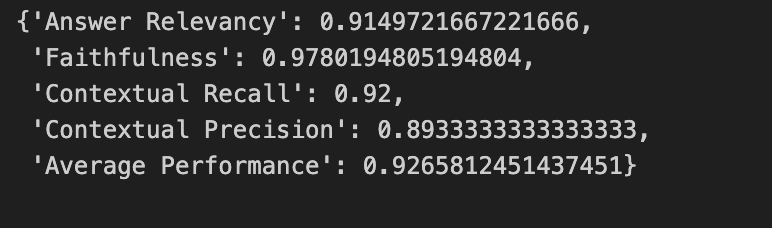

In [ ]:
scorer.get_summary(save_to_file=True)